In [32]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle

def line_id_color(line_id, T, cm):
    if line_id < 0:
        return 'red' 
    return cm(line_id / T)

def visualize_confidence(results):
    max_len = max(len(r["confidence"]) for r in results)
    C = np.full((len(results), max_len), np.nan)

    for i, r in enumerate(results):
        C[i, :len(r["confidence"])] = r["confidence"]

    plt.figure(figsize=(16, 16))
    plt.imshow(C, aspect="auto", cmap="inferno")
    plt.colorbar(label="confidence")
    plt.xlabel("pseudotime")
    plt.ylabel("corridor")
    plt.title("Confidence heatmap")
    plt.show()

def visualize_template(template):
    plt.figure(figsize=(8, 3))
    plt.plot(template, marker="o")
    plt.title("Canonical period template")
    plt.xlabel("Line ID")
    plt.ylabel("Signal value")
    plt.grid(True)
    plt.show()

def visualize_overlay(
    img,
    corridor_bbox,
    results,
    T,
    m,
    alpha_scale=0.8,
    show_ids=False,
    figsize=(16, 16),
):
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(img, cmap="gray")
    ax.set_title("Corridor line IDs and periods")
    ax.axis("off")
    cmap = plt.get_cmap("turbo", T)
    colors = ["red", "blue"]
    period_idx = 0

    for corr_idx, (bbox, res) in enumerate(zip(corridor_bbox, results)):
        x0, x1 = bbox["x0"], bbox["x1"]
        y0, y1 = bbox["y0"], bbox["y1"]

        signal = res["signal"]
        line_id = res["line_id"]
        conf = res["confidence"]
        offset = res["offset"]

        xs = list(range(x0, x1 + 1, m))
        period_start_x = None
        period_top = None
        period_bottom = None


        for i, x in enumerate(xs):
            

            lid = line_id[i] 
            c = conf[i]

            
            color = line_id_color(lid, T, cmap)
            alpha = alpha_scale * 1

            col = img[y0:y1+1, x]
            if np.all(col == 0):
                continue
            ys = np.flatnonzero(col)
            y_top = y0 + int(ys[0])
            y_bottom = y0 + int(ys[-1])


            if lid == 0:
                period_start_x = x
                period_top = y_top
                period_bottom = y_bottom

            elif lid == T - 1 and period_start_x is not None:
                width = x - period_start_x
                height = period_bottom - period_top

                col = colors[period_idx % 2]

                rect = Rectangle(
                    (period_start_x, period_top),  # bottom-left corner
                    width,
                    height,
                    linewidth=1,
                    edgecolor=col,
                    facecolor=col,
                    alpha=0.5
                )

                plt.gca().add_patch(rect)
                period_idx += 1

            ax.plot([x, x], [y_top, y_bottom],
                    color=color, alpha=alpha, linewidth=1)

        # draw bbox
        plt.plot([x0, x1], [y0, y0], color='red', linewidth=0.5)
        plt.plot([x0, x1], [y1, y1], color='red', linewidth=0.5)
        plt.plot([x0, x0], [y0, y1], color='red', linewidth=0.5)
        plt.plot([x1, x1], [y0, y1], color='red', linewidth=0.5)

        # annotate offset
        ax.text(x0, y0 - 5,
                f"offset={offset}",
                color="yellow",
                fontsize=8)

    plt.show()


In [28]:
from morphology_pipeline import dataset_creator
from tifffile import imread

background = r'..\test_1462.tif'
img = imread(background)
img = img[..., :3]
folder = r'..\Chip_1462_1_real'

pseudotime, corridors, corr_mask = dataset_creator.create_dataset(img, folder)

pseudotime


c:\Users\dmitr\Documents\Projects Coding\Nikita PhD\morphology_pipeline\.venv\lib\site-packages\cp_measure\core\measureobjectsizeshape.py:637: RuntimeWarning: divide by zero encountered in divide
  formfactor = 4.0 * numpy.pi * props["area"] / props["perimeter"] ** 2


Detected 23 corridors.


{'period': 17,
 'template': array([-6.25491355e-02,  5.43270984e-02,  1.44948405e-01,  1.91493865e-01,
         2.18108942e-01,  2.11466399e-01,  1.90794127e-01,  1.63686269e-01,
         1.46104488e-01,  8.96831331e-02, -1.72867015e-04, -1.08978032e-01,
        -1.81314502e-01, -2.38207711e-01, -2.79483356e-01, -3.02027760e-01,
        -2.38351624e-01]),
 'corridors': [{'signal': array([-1.82267609, -1.82267609, -1.4643495 , -1.4643495 , -1.64351279,
          -1.64351279, -1.4643495 , -1.2851862 , -0.74769632, -0.74769632,
          -0.74769632, -0.56853303, -0.56853303, -0.21020644, -0.03104315,
           0.14812015,  0.32728344,  0.32728344,  1.22309991,  1.7605898 ,
           2.11891638,  1.40226321,  0.86477333,  0.14812015, -0.03104315,
          -0.38936973, -0.74769632, -0.74769632, -0.56853303, -0.21020644,
          -0.21020644, -0.38936973, -0.56853303, -0.56853303, -0.74769632,
          -0.21020644,  0.68561003,  2.47724297,  2.11891638,  1.22309991,
           0.148120

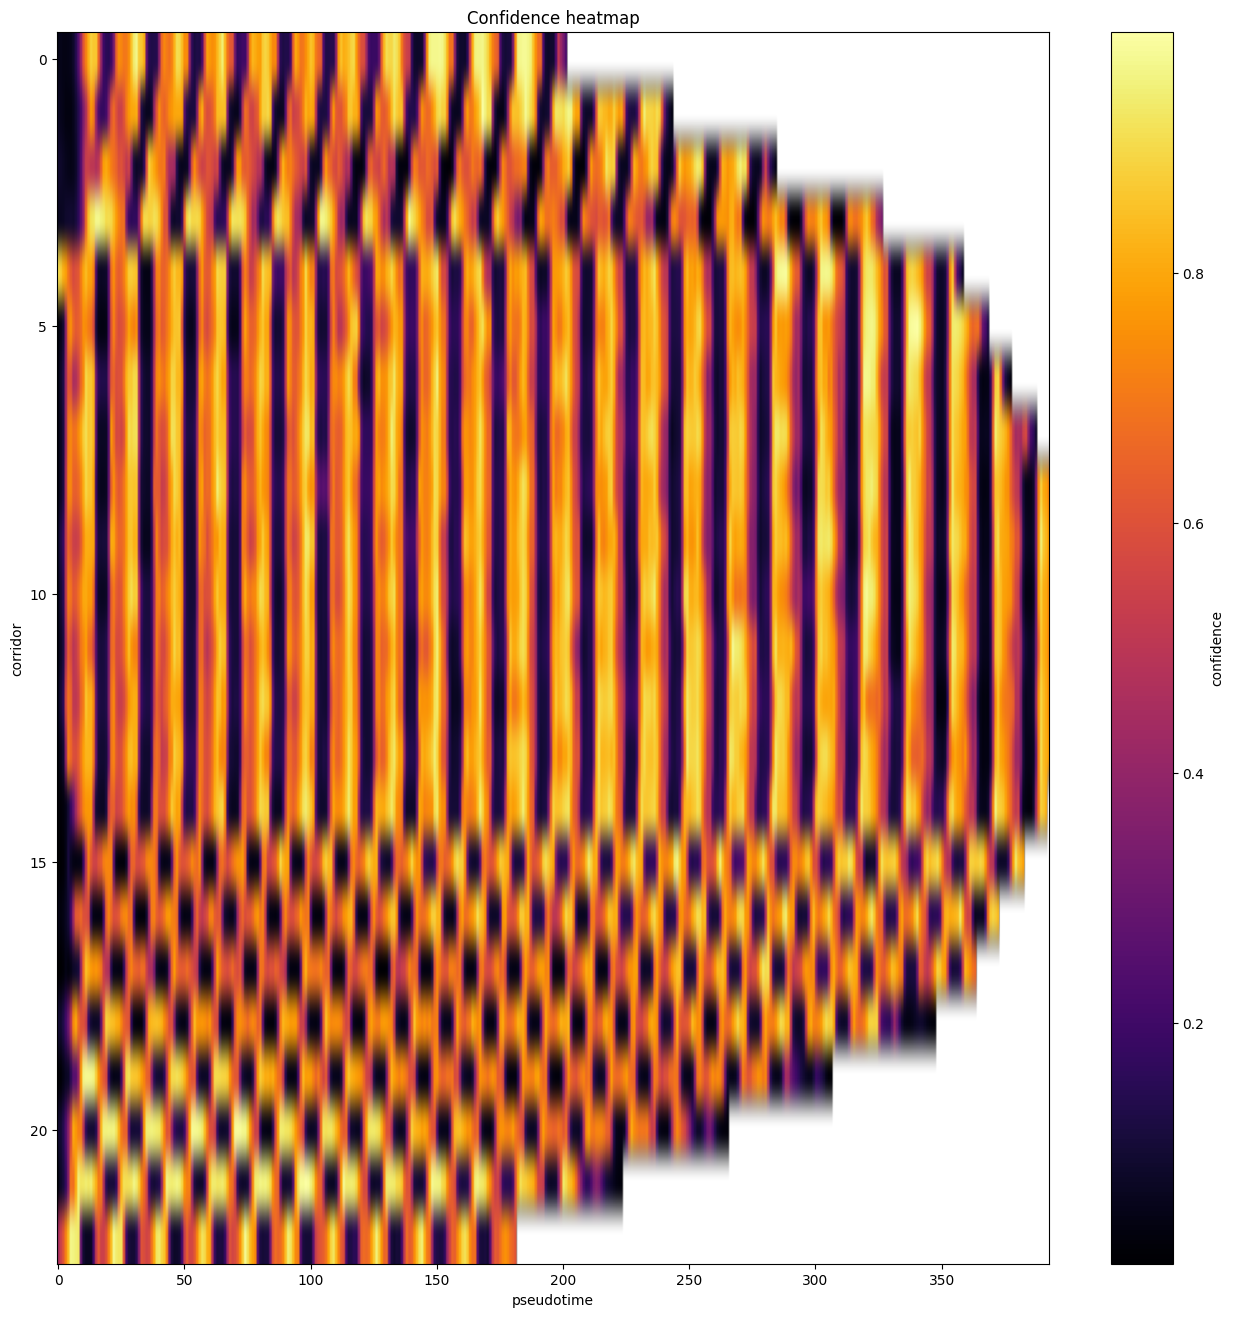

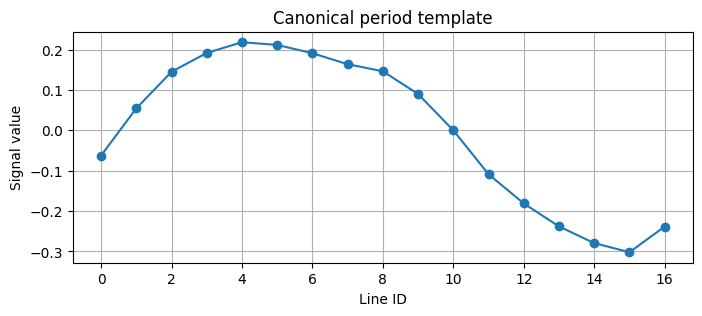

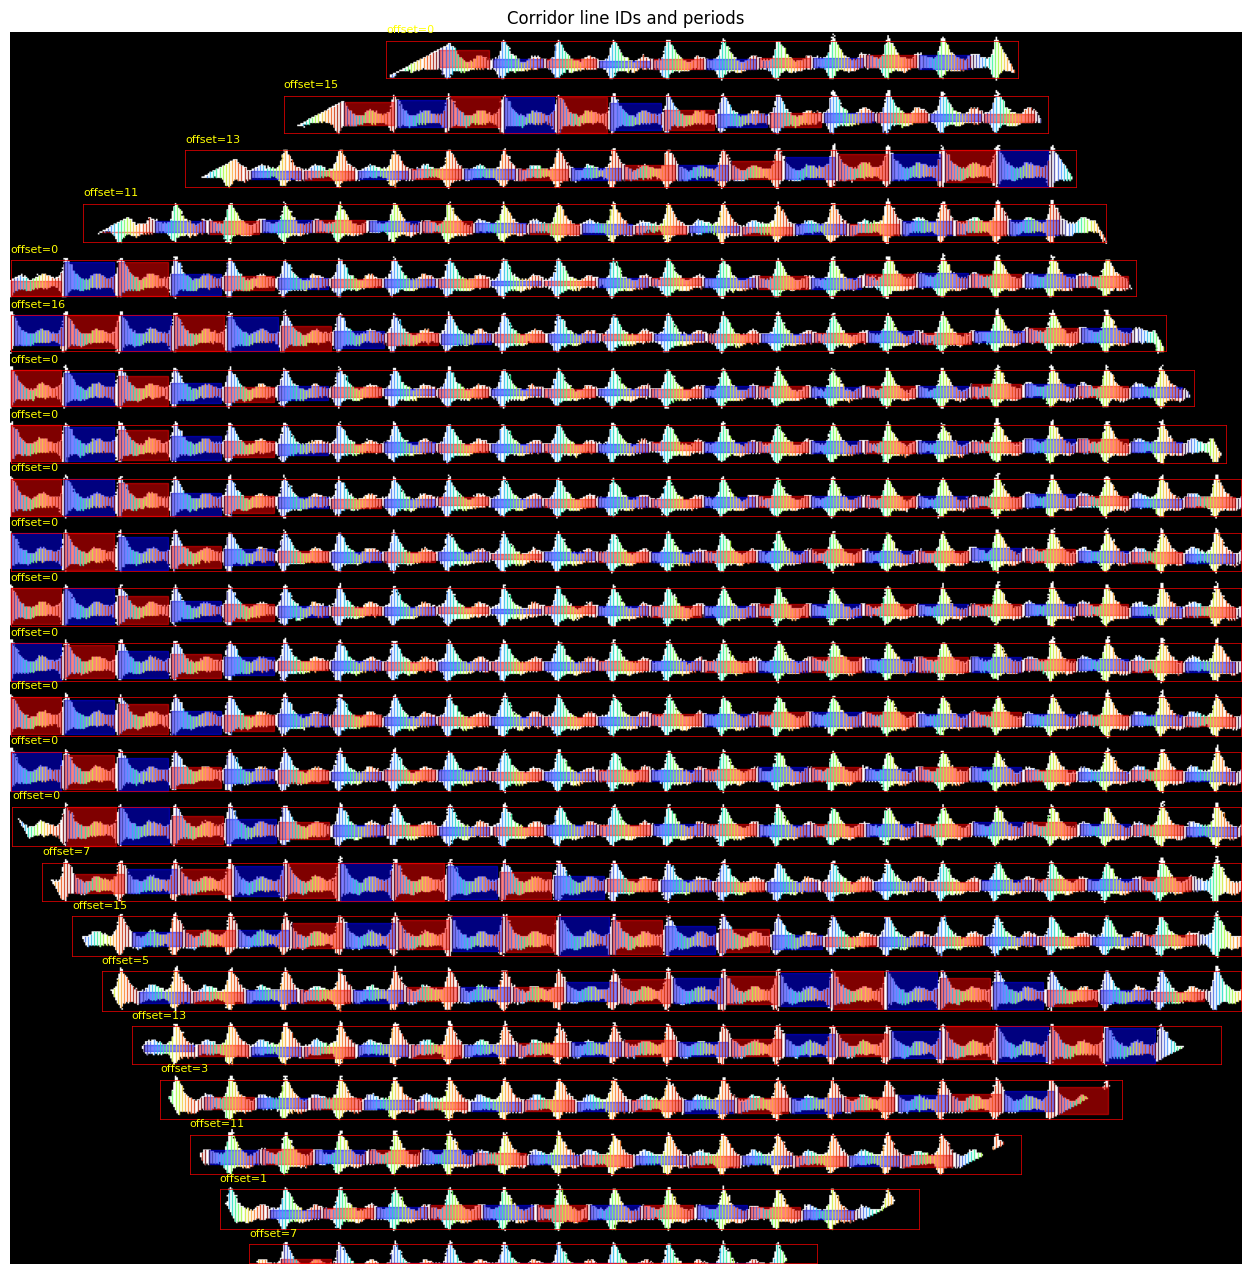

17


: 

In [ ]:
visualize_confidence(pseudotime["corridors"])
visualize_template(pseudotime["template"])
visualize_overlay(
    img=corr_mask,
    corridor_bbox=corridors,
    results=pseudotime["corridors"],
    T=pseudotime["period"],
    m=2,
    show_ids=False,
)
print(pseudotime['period'])